# Sixsphere en notebook

Version notebook du script `sixsphere.py` avec affichage via `display(...)`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import L_BFGS_B
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA
from qiskit_aer import AerSimulator
from sklearn.model_selection import train_test_split

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import SamplerV2 as Sampler
from scipy.optimize import minimize
from qiskit_aer import StatevectorSimulator

# -- Configuration -----------------------------------------------------------

# Dataset
n = 1000  # Number of generated points
TEST_SIZE = 0.2  # Fraction used for test set
SEED = 1  # Random seed (data split & optimizer init)
N_DIM = 6  # Features dimension

# Optimization
MAXITER = 1000  # minimizer max iterations
optimizer = COBYLA(maxiter=MAXITER)

# Noise
USE_NOISE = False
NOISE_RATE = 0.02
# --------------------------------------------------------------------------
REUPLOAD_SHOTS = 2048

if USE_NOISE:
    print("Construction du simulateur BRUITE...")
    nm = NoiseModel()
    # Erreur sur les portes simples (1 qubit)
    err1 = depolarizing_error(NOISE_RATE, 1)
    nm.add_all_qubit_quantum_error(err1, ["u", "h", "ry", "rz"])
    # Erreur sur l'intrication (2 qubits) - on met souvent 5x plus
    err2 = depolarizing_error(NOISE_RATE * 5, 2)
    nm.add_all_qubit_quantum_error(err2, ["cx"])

    # On cree le backend (ton ancien AerSimulator)
    backend = AerSimulator(noise_model=nm, method="density_matrix")
    # On l'enveloppe pour le rendre compatible VQC
    sampler = Sampler(backend)
else:
    print("-> Mode IDEAL")
    sampler = Sampler(AerSimulator())


def generate_nsphere_data(n_samples, n_dim, radius=None):
    # Generation de points entre -1 et 1
    X = np.random.uniform(-1, 1, (n_samples, n_dim))
    # Le rayon par defaut est choisi pour equilibrer les classes
    if radius is None:
        radius = np.sqrt(n_dim / 3)

    # Calcul de la norme euclidienne au carre
    dist_sq = np.sum(X**2, axis=1)
    y = (dist_sq >= radius**2).astype(int)

    return X, y, radius


X, y, R = generate_nsphere_data(n_samples=n, n_dim=N_DIM)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(X_train.shape, y_train.shape)

# --- Re-uploading 2 qubits (n_dim=6) ---

# Hyperparametres du modele re-uploading 2 qubits
RC_REUPLOAD_2Q = 10  # nombre de couches de re-uploading
MAXITER_REUPLOAD_2Q = 500
USE_REUPLOAD_2Q = N_DIM == 6

print(f"USE_REUPLOAD_2Q = {USE_REUPLOAD_2Q}")
if not USE_REUPLOAD_2Q:
    print("Le bloc re-uploading 2 qubits ci-dessous est prevu pour N_DIM = 6.")

-> Mode IDEAL
(800, 6) (800,)
USE_REUPLOAD_2Q = True


Apercu du circuit weak learner (2 qubits) :


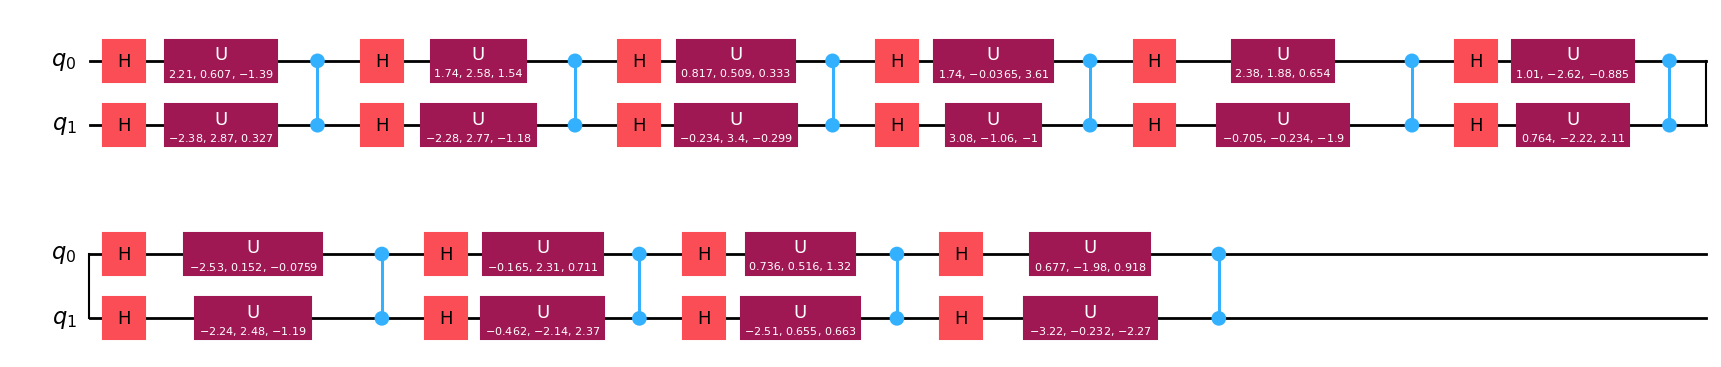

In [16]:
def U_su2_reupload_2q(qc, theta_q0, omega_q0, theta_q1, omega_q1, x, qubit0=0, qubit1=1):
    """
    Structure 2 qubits a chaque layer :
    - U(theta_q0 + omega_q0 * x[0:3]) sur qubit 0 avec les 3 premieres coordonnees
    - U(theta_q1 + omega_q1 * x[3:6]) sur qubit 1 avec les 3 dernieres coordonnees
    """
    qc.u(
        theta_q0[0] + omega_q0[0] * x[0],
        theta_q0[1] + omega_q0[1] * x[1],
        theta_q0[2] + omega_q0[2] * x[2],
        qubit0,
    )
    qc.u(
        theta_q1[0] + omega_q1[0] * x[3],
        theta_q1[1] + omega_q1[1] * x[4],
        theta_q1[2] + omega_q1[2] * x[5],
        qubit1,
    )


def create_reupload_circuit_2q(x, theta, omega, measure=False):
    """
    Circuit re-uploading a 2 qubits pour N_DIM = 6.
    Chaque layer : H(0), H(1), U sur q0 et q1, CZ(0,1), etc.
    theta shape: (RC_REUPLOAD_2Q, 2, 3) - 2 qubits, 3 params chacun
    omega shape: (RC_REUPLOAD_2Q, 2, 3)
    """
    qc = QuantumCircuit(2)
    for r in range(RC_REUPLOAD_2Q):
        qc.h(0)
        qc.h(1)
        U_su2_reupload_2q(
            qc, theta[r, 0], omega[r, 0], theta[r, 1], omega[r, 1], x, qubit0=0, qubit1=1
        )
        qc.cz(0, 1)  # Intrication
    if measure:
        qc.measure_all()
    return qc


def get_reupload_probs_batch_2q(circuits, shots=REUPLOAD_SHOTS):
    """
    Execute les circuits 2 qubits et retourne les probabilites.
    Cette fois on regarde le qubit 1 (ou on peut moyenner les deux).
    """
    probs = []

    if USE_NOISE:
        measured_circuits = []
        for qc in circuits:
            qc_m = qc.copy()
            if qc_m.num_clbits == 0:
                qc_m.measure_all()
            measured_circuits.append(qc_m)

        transpiled_circuits = transpile(measured_circuits, backend)
        result = backend.run(transpiled_circuits, shots=shots).result()

        for qc_t in transpiled_circuits:
            counts = result.get_counts(qc_t)
            # On prend les probabilites du qubit 1 dans les outcomes
            p0 = (counts.get("00", 0) + counts.get("10", 0)) / shots
            p1 = (counts.get("01", 0) + counts.get("11", 0)) / shots
            probs.append((p0, p1))
    else:
        sim = StatevectorSimulator()
        for qc in circuits:
            sv = sim.run(qc).result().get_statevector()
            # Pour 2 qubits, |psi> = a00|00> + a01|01> + a10|10> + a11|11>
            p0 = float(np.abs(sv[0]) ** 2 + np.abs(sv[2]) ** 2)
            p1 = float(np.abs(sv[1]) ** 2 + np.abs(sv[3]) ** 2)
            probs.append((p0, p1))

    return probs


def reupload_cost_weighted_2q(params, X, y):
    """
    Cout pour 2 qubits.
    params = [theta_q0_flat, theta_q1_flat, omega_q0_flat, omega_q1_flat, alphas]
    """
    n_params_per_q = 3 * RC_REUPLOAD_2Q
    theta_q0_flat = params[:n_params_per_q]
    theta_q1_flat = params[n_params_per_q : 2 * n_params_per_q]
    omega_q0_flat = params[2 * n_params_per_q : 3 * n_params_per_q]
    omega_q1_flat = params[3 * n_params_per_q : 4 * n_params_per_q]
    alphas = params[4 * n_params_per_q :]

    theta_q0 = theta_q0_flat.reshape(RC_REUPLOAD_2Q, 3)
    theta_q1 = theta_q1_flat.reshape(RC_REUPLOAD_2Q, 3)
    omega_q0 = omega_q0_flat.reshape(RC_REUPLOAD_2Q, 3)
    omega_q1 = omega_q1_flat.reshape(RC_REUPLOAD_2Q, 3)

    # Construire les thetas et omegas au format attendu par create_reupload_circuit_2q
    theta = np.stack([theta_q0, theta_q1], axis=1)  # shape: (RC_REUPLOAD_2Q, 2, 3)
    omega = np.stack([omega_q0, omega_q1], axis=1)

    circuits = [create_reupload_circuit_2q(x, theta, omega, measure=False) for x in X]
    probs = get_reupload_probs_batch_2q(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        weight = alphas[y_target] ** 2
        total_cost += weight * ((p0 - y_expected[0]) ** 2 + (p1 - y_expected[1]) ** 2)

    return 0.5 * total_cost / len(X)


def unpack_reupload_params_2q(params):
    n_params_per_q = 3 * RC_REUPLOAD_2Q
    theta_q0 = params[:n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    theta_q1 = params[n_params_per_q : 2 * n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    omega_q0 = params[2 * n_params_per_q : 3 * n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    omega_q1 = params[3 * n_params_per_q : 4 * n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    alphas = params[4 * n_params_per_q :]

    theta = np.stack([theta_q0, theta_q1], axis=1)
    omega = np.stack([omega_q0, omega_q1], axis=1)
    return theta, omega, alphas


def optimize_reupload_parameters_2q(X, y):
    rng = np.random.default_rng(SEED)
    # 4 * 3 * RC_REUPLOAD_2Q + 2 params
    init = rng.uniform(-np.pi, np.pi, size=4 * 3 * RC_REUPLOAD_2Q + 2)

    reupload_cost_history_2q = []

    def objective(params):
        cost = reupload_cost_weighted_2q(params, X, y)
        reupload_cost_history_2q.append(cost)
        print(f"Iteration {len(reupload_cost_history_2q):3d} | cost = {cost:.6f}")
        return cost

    res = minimize(
        objective, init, method="COBYLA", options={"maxiter": MAXITER_REUPLOAD_2Q}
    )

    theta_opt, omega_opt, alphas_opt = unpack_reupload_params_2q(res.x)
    return res, theta_opt, omega_opt, alphas_opt, reupload_cost_history_2q


def predict_reupload_batch_2q(X, theta, omega):
    circuits = [create_reupload_circuit_2q(x, theta, omega, measure=False) for x in X]
    probs = get_reupload_probs_batch_2q(circuits)
    return np.array([0 if p0 >= p1 else 1 for p0, p1 in probs])


def evaluate_reupload_2q(X, y, theta, omega):
    y_pred = predict_reupload_batch_2q(X, theta, omega)
    accuracy = np.mean(y_pred == y)
    return accuracy, y_pred


if USE_REUPLOAD_2Q:
    # Apercu visuel de la structure d'un weak learner (parametres aleatoires)
    rng_preview = np.random.default_rng(SEED + 99)
    theta_preview_2q = rng_preview.uniform(-np.pi, np.pi, size=(RC_REUPLOAD_2Q, 2, 3))
    omega_preview_2q = rng_preview.uniform(-1.0, 1.0, size=(RC_REUPLOAD_2Q, 2, 3))
    qc_weak_preview_2q = create_reupload_circuit_2q(
        X_train[0], theta_preview_2q, omega_preview_2q, measure=False
    )
    print("Apercu du circuit weak learner (2 qubits) :")
    display(qc_weak_preview_2q.draw("mpl"))

Entrainement du modele re-uploading (2 qubits)...


Iteration   1 | cost = 0.701337
Iteration   2 | cost = 0.675453
Iteration   3 | cost = 0.686292
Iteration   4 | cost = 0.679901
Iteration   5 | cost = 0.652740
Iteration   6 | cost = 0.656984
Iteration   7 | cost = 0.685131
Iteration   8 | cost = 0.647468
Iteration   9 | cost = 0.621619
Iteration  10 | cost = 0.642298
Iteration  11 | cost = 0.593205
Iteration  12 | cost = 0.633489
Iteration  13 | cost = 0.608989
Iteration  14 | cost = 0.621193
Iteration  15 | cost = 0.613725
Iteration  16 | cost = 0.639328
Iteration  17 | cost = 0.601843
Iteration  18 | cost = 0.628569
Iteration  19 | cost = 0.640217
Iteration  20 | cost = 0.642488
Iteration  21 | cost = 0.626509
Iteration  22 | cost = 0.602211
Iteration  23 | cost = 0.607995
Iteration  24 | cost = 0.630003
Iteration  25 | cost = 0.614919
Iteration  26 | cost = 0.609714
Iteration  27 | cost = 0.594336
Iteration  28 | cost = 0.632054
Iteration  29 | cost = 0.625291
Iteration  30 | cost = 0.593205
Iteration  31 | cost = 0.631868
Iteratio

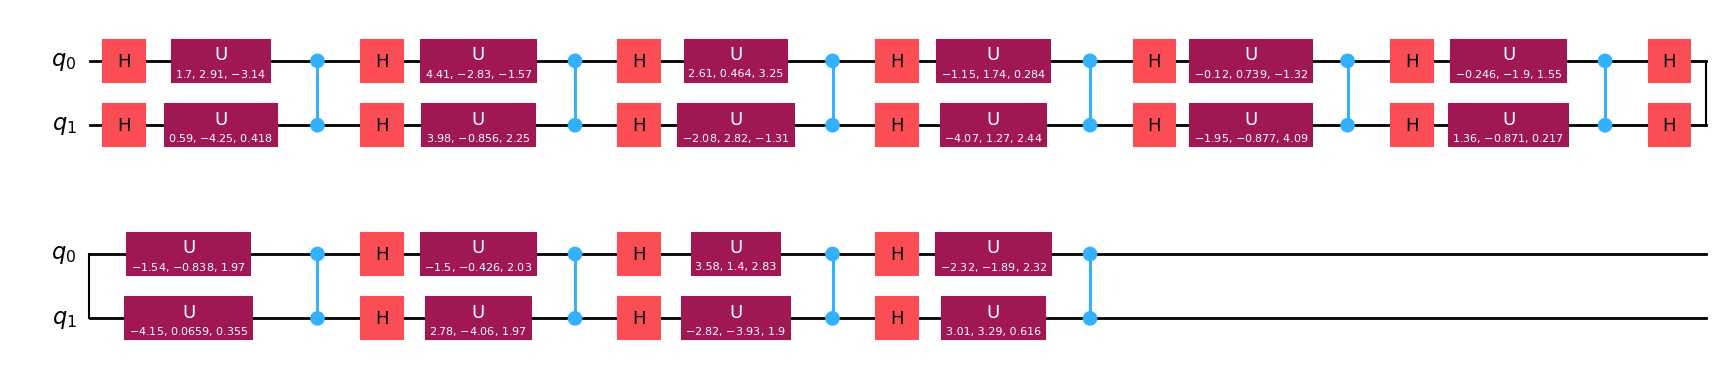

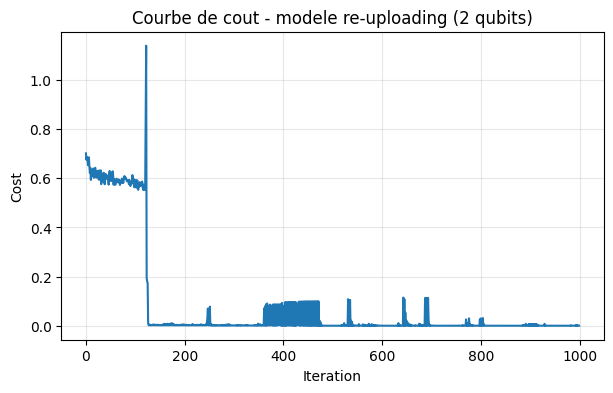

Re-uploading 2 qubits (N_DIM=6) : 49.00%


In [17]:
if USE_REUPLOAD_2Q:
    print("Entrainement du modele re-uploading (2 qubits)...")
    reupload_res_2q, theta_re_2q, omega_re_2q, alpha_re_2q, reupload_cost_history_2q = optimize_reupload_parameters_2q(
        X_train, y_train
    )

    reupload_accuracy_2q, y_pred_reupload_2q = evaluate_reupload_2q(
        X_test, y_test, theta_re_2q, omega_re_2q
    )
    print(f"Precision test re-uploading 2Q : {100 * reupload_accuracy_2q:.2f}%")
else:
    print("Bloc non execute car N_DIM != 6")

if USE_REUPLOAD_2Q:
    print("Circuit re-uploading 2 qubits appris :")
    qc_reupload_2q = create_reupload_circuit_2q(X_train[0], theta_re_2q, omega_re_2q, measure=False)
    display(qc_reupload_2q.draw("mpl"))

if USE_REUPLOAD_2Q:
    plt.figure(figsize=(7, 4))
    plt.plot(reupload_cost_history_2q)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.title("Courbe de cout - modele re-uploading (2 qubits)")
    plt.grid(True, alpha=0.3)
    plt.show()

if USE_REUPLOAD_2Q:
    print(f"Re-uploading 2 qubits (N_DIM=6) : {reupload_accuracy_2q * 100:.2f}%")

In [18]:
N_ESTIMATORS_REUPLOAD_2Q = 5
MAXITER_WEAK_REUPLOAD_2Q = MAXITER_REUPLOAD_2Q


def reupload_cost_weighted_samples_2q(params, X, y, sample_weights):
    """Cout AdaBoost pour 2 qubits avec poids d'echantillons"""
    n_params_per_q = 3 * RC_REUPLOAD_2Q
    theta_q0_flat = params[:n_params_per_q]
    theta_q1_flat = params[n_params_per_q : 2 * n_params_per_q]
    omega_q0_flat = params[2 * n_params_per_q : 3 * n_params_per_q]
    omega_q1_flat = params[3 * n_params_per_q : 4 * n_params_per_q]

    theta_q0 = theta_q0_flat.reshape(RC_REUPLOAD_2Q, 3)
    theta_q1 = theta_q1_flat.reshape(RC_REUPLOAD_2Q, 3)
    omega_q0 = omega_q0_flat.reshape(RC_REUPLOAD_2Q, 3)
    omega_q1 = omega_q1_flat.reshape(RC_REUPLOAD_2Q, 3)

    theta = np.stack([theta_q0, theta_q1], axis=1)
    omega = np.stack([omega_q0, omega_q1], axis=1)

    circuits = [create_reupload_circuit_2q(x, theta, omega, measure=False) for x in X]
    probs = get_reupload_probs_batch_2q(circuits)

    total_cost = 0.0
    for i, y_target in enumerate(y):
        p0, p1 = probs[i]
        y_expected = (1.0, 0.0) if y_target == 0 else (0.0, 1.0)
        total_cost += sample_weights[i] * ((p0 - y_expected[0]) ** 2 + (p1 - y_expected[1]) ** 2)

    return 0.5 * total_cost / np.sum(sample_weights)


def optimize_reupload_weak_learner_2q(X, y, sample_weights, seed):
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=4 * 3 * RC_REUPLOAD_2Q)

    weak_cost_history = []

    def objective(params):
        cost = reupload_cost_weighted_samples_2q(params, X, y, sample_weights)
        weak_cost_history.append(cost)
        return cost

    res = minimize(
        objective,
        init,
        method="COBYLA",
        options={"maxiter": MAXITER_WEAK_REUPLOAD_2Q},
    )

    n_params_per_q = 3 * RC_REUPLOAD_2Q
    theta_q0 = res.x[:n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    theta_q1 = res.x[n_params_per_q : 2 * n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    omega_q0 = res.x[2 * n_params_per_q : 3 * n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)
    omega_q1 = res.x[3 * n_params_per_q : 4 * n_params_per_q].reshape(RC_REUPLOAD_2Q, 3)

    theta = np.stack([theta_q0, theta_q1], axis=1)
    omega = np.stack([omega_q0, omega_q1], axis=1)
    return theta, omega, res.fun, weak_cost_history


def train_adaboost_reupload_2q(X_train, y_train, n_estimators=N_ESTIMATORS_REUPLOAD_2Q):
    n = len(y_train)
    weights = np.ones(n) / n
    estimators = []
    weak_cost_histories = []

    for i in range(n_estimators):
        theta, omega, cost, weak_history = optimize_reupload_weak_learner_2q(
            X_train, y_train, weights, seed=SEED + 200 + i
        )
        weak_cost_histories.append(weak_history)

        y_pred = predict_reupload_batch_2q(X_train, theta, omega)
        incorrect = (y_pred != y_train).astype(float)
        eps = np.dot(weights, incorrect)
        eps = np.clip(eps, 1e-10, 1 - 1e-10)

        alpha = 0.5 * np.log((1 - eps) / eps)

        y_signed = np.where(y_train == 0, -1.0, 1.0)
        h_signed = np.where(y_pred == 0, -1.0, 1.0)
        weights *= np.exp(-alpha * y_signed * h_signed)
        weights /= np.sum(weights)

        estimators.append((theta, omega, alpha))
        print(f"round {i + 1:02d} | cost={cost:.4f} eps={eps:.4f} alpha={alpha:.4f}")

    return estimators, weak_cost_histories


def predict_adaboost_reupload_2q(X, estimators):
    scores = np.zeros(len(X))
    for theta, omega, alpha in estimators:
        h_signed = np.where(predict_reupload_batch_2q(X, theta, omega) == 0, -1.0, 1.0)
        scores += alpha * h_signed
    return np.where(scores >= 0, 1, 0)


def evaluate_adaboost_reupload_2q(X, y, estimators, positive_label=1):
    y_pred = predict_adaboost_reupload_2q(X, estimators)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    fn = np.sum((y_pred != positive_label) & (y == positive_label))
    tn = np.sum((y_pred != positive_label) & (y != positive_label))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = np.mean(y_pred == y)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "precision": precision,
        "accuracy": accuracy,
        "recall": recall,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "y_pred": y_pred,
    }

In [19]:
if USE_REUPLOAD_2Q:
    print("Entrainement AdaBoost (base learner: re-uploading 2 qubits)...")
    estimators_reupload_boost_2q, weak_cost_histories_2q = train_adaboost_reupload_2q(
        X_train, y_train, n_estimators=N_ESTIMATORS_REUPLOAD_2Q
    )
    metrics_reupload_boost_2q = evaluate_adaboost_reupload_2q(X_test, y_test, estimators_reupload_boost_2q)
    y_pred_reupload_boost_2q = metrics_reupload_boost_2q["y_pred"]
    reupload_boost_accuracy_2q = metrics_reupload_boost_2q["accuracy"]
    print(
        f"AdaBoost re-uploading 2Q | precision={metrics_reupload_boost_2q['precision']:.4f} "
        f"recall={metrics_reupload_boost_2q['recall']:.4f} accuracy={reupload_boost_accuracy_2q:.4f}"
    )

    plt.figure(figsize=(8, 4))
    for i, history in enumerate(weak_cost_histories_2q):
        plt.plot(history, label=f"Weak learner {i + 1}", alpha=0.9)
    plt.xlabel("Iteration COBYLA")
    plt.ylabel("Cost")
    plt.title("Evolution de la fonction cout COBYLA (AdaBoost 2Q)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    estimators_reupload_boost_2q = None
    weak_cost_histories_2q = None
    metrics_reupload_boost_2q = None
    y_pred_reupload_boost_2q = None
    reupload_boost_accuracy_2q = None

if USE_REUPLOAD_2Q and reupload_boost_accuracy_2q is not None:
    print("=== Comparaison finale (AdaBoost) ===")
    print(f"AdaBoost re-uploading 2 qubits (N_DIM=6) : {reupload_boost_accuracy_2q * 100:.2f}%")

Entrainement AdaBoost (base learner: re-uploading 2 qubits)...


KeyboardInterrupt: 